In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('22_Lockbox_Q2_2026.ipynb', source, ())

# 22 - Lockbox: Q2 2026 evaluation

## Methodology

Six policies frozen before Q2 were evaluated over `[2026-04-01, 2026-07-01)` without refitting or retuning. BTC Qualified Union versus LSTM DZ55 is the sole confirmatory comparison; USA500 and USATECH are descriptive transport tests.

BTC Qualified Union combines LSTM DZ55 at confidence 0.75 with every directional Linear SVM DZ75 prediction, vetoing simultaneous opposite signals. Both BTC policies use TP200/SL100, a one-M15 hold and 10 bps round-trip costs. USA500 uses DeBERTa-matched SVM DZ15 at 0.40; USATECH uses LLM-matched LSTM DZ15 at 0.65. Each index has an equal-weight all-nine probability comparator at 0.55, with admitted VIX inputs and costs of 2 bps for USA500 and 3 bps for USATECH.

The nine models are Logistic Regression, Decision Tree, Random Forest, Linear SVM, XGBoost, CatBoost, MLP, LSTM and GRU. Net is additive; daily Sharpe and Sortino use all 91 zero-filled UTC days. This completed replay contained no fresh scored Q2 news/direct-event rows. Notebook 17 separately tests fresh-feed sensitivity, so sentiment-arm names alone do not establish fresh coverage.


In [2]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

CODE_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
STATE_ROOT = CODE_ROOT / "experiments" / "cache" / "final_q2_lockbox"

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def resolve_bound_path(value):
    path = Path(value)
    if path.anchor or ":" in str(value):
        raise ValueError("Artifact paths must be relative to the result directory")
    root = RESULT_ROOT.resolve(strict=True)
    resolved = (root / path).resolve(strict=True)
    resolved.relative_to(root)
    if not resolved.is_file():
        raise FileNotFoundError(resolved)
    return resolved

def validate_manifest():
    opened = json.loads((STATE_ROOT / "OPENED.json").read_text(encoding="utf-8"))
    protocol_hash = opened["identity"]["protocol_hash"]
    result_root = STATE_ROOT / protocol_hash
    complete = json.loads((result_root / "COMPLETE.json").read_text(encoding="utf-8"))
    manifest_path = result_root / "manifest.json"
    manifest_sha256 = sha256(manifest_path)
    assert complete["result_hashes"]["manifest"] == manifest_sha256
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    assert manifest["opening_identity"] == opened["identity"]
    return result_root, manifest, manifest_sha256

def validate_all_artifacts(manifest):
    artifact_hashes = manifest["artifact_hashes"]
    for key, entry in artifact_hashes.items():
        assert sha256(resolve_bound_path(entry["path"])) == entry["sha256"], key
    return {key: resolve_bound_path(entry["path"]) for key, entry in artifact_hashes.items()}

RESULT_ROOT, FINAL_MANIFEST, MANIFEST_SHA256 = validate_manifest()
ARTIFACTS = validate_all_artifacts(FINAL_MANIFEST)
VALIDATED = True

In [3]:
LABELS = {
    "btc_qualified_union_v1": "BTC Qualified Union",
    "btc_lstm_dz55": "BTC LSTM DZ55 control",
    "usa500_best_single_deberta_svm": "USA500 DeBERTa SVM",
    "usa500_deberta_soft_vote": "USA500 all-nine soft vote",
    "usatech_best_single_deepseek_lstm": "USATECH LLM LSTM",
    "usatech_deepseek_soft_vote": "USATECH all-nine soft vote",
}

def read_table(key):
    assert VALIDATED
    return pd.read_parquet(ARTIFACTS[key])

def require_table(frame, numeric):
    assert len(frame) > 0
    values = frame.loc[:, numeric].to_numpy(dtype=float)
    assert np.isfinite(values).all()
    assert np.any(values != 0.0)
    return frame

def economics_table(stream):
    frame = read_table("summaries").loc[lambda x: x["stream"].eq(stream)].copy()
    frame["Policy"] = frame["candidate_id"].map(LABELS)
    frame["Net %"] = 100 * frame["net_return"]
    frame["Sharpe"] = frame["daily_sharpe"]
    frame["Sortino"] = frame["daily_sortino"]
    frame["Max drawdown %"] = 100 * frame["max_drawdown"]
    frame = frame.rename(columns={
        "trades": "Trades", "trades_per_day": "Trades/day",
        "long_trades": "LONG", "short_trades": "SHORT",
    })
    columns = ["Policy", "Trades", "Trades/day", "LONG", "SHORT", "Net %", "Sharpe", "Sortino", "Max drawdown %"]
    return require_table(frame[columns], ["Trades", "Net %", "Sharpe", "Sortino"])

In [4]:
score_keys = [
    key for key in ARTIFACTS
    if key.startswith("sentiment__scores") and key.endswith(".parquet")
]
fresh_sentiment_rows = sum(len(pd.read_parquet(ARTIFACTS[key])) for key in score_keys)
integrity = pd.DataFrame([{
    "State": "COMPLETE",
    "Interval": "2026-04-01 to 2026-07-01 (UTC, end exclusive)",
    "Frozen candidates": len(FINAL_MANIFEST["candidate_ids"]),
    "Fresh scored news/direct rows": fresh_sentiment_rows,
    "Retuning": "None",
    "Manifest SHA-256": MANIFEST_SHA256[:16] + "…",
}])
coverage = "no fresh scored news/direct rows" if fresh_sentiment_rows == 0 else f"{fresh_sentiment_rows} fresh scored rows"


## BTC policy economics

The table compares both BTC policies over the same 91-day calendar after the fixed 10 bps round-trip cost. Rows are sorted by Net; Sharpe and Sortino are daily and drawdown is reported as a positive loss magnitude.


In [5]:
btc_table = economics_table("btcusdt").sort_values("Net %", ascending=False)
display(btc_table)
leader = btc_table.iloc[0]


,Policy,Trades,Trades/day,LONG,SHORT,Net %,Sharpe,Sortino,Max drawdown %
0,BTC LSTM DZ55 control,20,0.219780,4,16,-0.970215,-0.857537,-1.602729,3.021252
1,BTC Qualified Union,23,0.252747,7,16,-2.197567,-1.820108,-2.688526,4.121252


## Confirmatory BTC contrast

The sole confirmatory contrast is Qualified Union minus LSTM total Net. The 95% interval uses 5,000 fixed Monday-Sunday block resamples with seed 42. Here Net % is the difference in percentage points; Sharpe and Sortino describe Qualified Union, not a difference in ratios.


In [6]:
contrast = read_table("paired_contrasts").loc[lambda x: x["stream"].eq("btcusdt")].copy()
summary = read_table("summaries").set_index("candidate_id")
contrast["Net %"] = 100 * contrast["point_estimate"]
contrast["Sharpe"] = contrast["policy_id"].map(summary["daily_sharpe"])
contrast["Sortino"] = contrast["policy_id"].map(summary["daily_sortino"])
contrast["95% interval, pp"] = contrast.apply(lambda row: f"[{100*row.lower_95:.2f}, {100*row.upper_95:.2f}]", axis=1)
contrast["Support"] = contrast["primary_confirmatory_support"].map({True: "Yes", False: "No"})
contrast_view = require_table(contrast[["Net %", "Sharpe", "Sortino", "95% interval, pp", "Support"]], ["Net %", "Sharpe", "Sortino"]).sort_values("Net %", ascending=False)
display(contrast_view)
row = contrast.iloc[0]


,Net %,Sharpe,Sortino,"95% interval, pp",Support
0,-1.227352,-1.820108,-2.688526,"[-3.55, 0.00]",No


## USA500 transport result

The frozen DeBERTa SVM and equal-weight all-nine comparator use admitted VIX and deduct 2 bps round trip. These descriptive rows are sorted by Net and have no fresh Q2 news/direct-event scores in this replay.


In [7]:
usa500_table = economics_table("usa500").sort_values("Net %", ascending=False)
display(usa500_table)
leader = usa500_table.iloc[0]


,Policy,Trades,Trades/day,LONG,SHORT,Net %,Sharpe,Sortino,Max drawdown %
2,USA500 all-nine soft vote,3,0.032967,3,0,0.909503,2.746591,0.000000,0.000000
3,USA500 DeBERTa SVM,1,0.010989,1,0,-0.124961,-2.002745,-2.002745,0.124961


## USATECH transport result

The frozen LLM LSTM and equal-weight all-nine comparator use admitted VIX and deduct 3 bps round trip. These descriptive rows are sorted by Net and have no fresh Q2 news/direct-event scores in this replay.


In [8]:
usatech_table = economics_table("usatech").sort_values("Net %", ascending=False)
display(usatech_table)
leader = usatech_table.iloc[0]


,Policy,Trades,Trades/day,LONG,SHORT,Net %,Sharpe,Sortino,Max drawdown %
4,USATECH LLM LSTM,2,0.021978,2,0,1.061844,2.569469,0.0,0.0
5,USATECH all-nine soft vote,2,0.021978,1,1,0.859459,2.192746,0.0,0.0


## Side coverage and cost sensitivity

The table doubles registered costs while keeping every trade unchanged. LONG/SHORT counts and normal-cost Net, Sharpe and Sortino give context for the stress result.


In [9]:
stress = read_table("summaries").copy()
stress["Policy"] = stress["candidate_id"].map(LABELS)
stress["Net %"] = 100 * stress["net_return"]
stress["Sharpe"] = stress["daily_sharpe"]
stress["Sortino"] = stress["daily_sortino"]
stress["2x-cost Net %"] = 100 * stress["stress_2x_net_return"]
stress = stress.rename(columns={"long_trades": "LONG", "short_trades": "SHORT"})
stress_view = require_table(stress[["Policy", "LONG", "SHORT", "Net %", "Sharpe", "Sortino", "2x-cost Net %"]], ["LONG", "SHORT", "Net %", "Sharpe", "Sortino", "2x-cost Net %"]).sort_values("Net %", ascending=False)
display(stress_view)
survivors = int(stress_view["2x-cost Net %"].gt(0).sum())


,Policy,LONG,SHORT,Net %,Sharpe,Sortino,2x-cost Net %
4,USATECH LLM LSTM,2,0,1.061844,2.569469,0.000000,1.001844
2,USA500 all-nine soft vote,3,0,0.909503,2.746591,0.000000,0.849503
5,USATECH all-nine soft vote,1,1,0.859459,2.192746,0.000000,0.799459
3,USA500 DeBERTa SVM,1,0,-0.124961,-2.002745,-2.002745,-0.144961
0,BTC LSTM DZ55 control,4,16,-0.970215,-0.857537,-1.602729,-2.970215
1,BTC Qualified Union,7,16,-2.197567,-1.820108,-2.688526,-4.497567


## Cumulative net returns

Each panel sums cost-adjusted daily Net on the same zero-filled UTC calendar. Markets remain separate; the figure does not pool their returns.


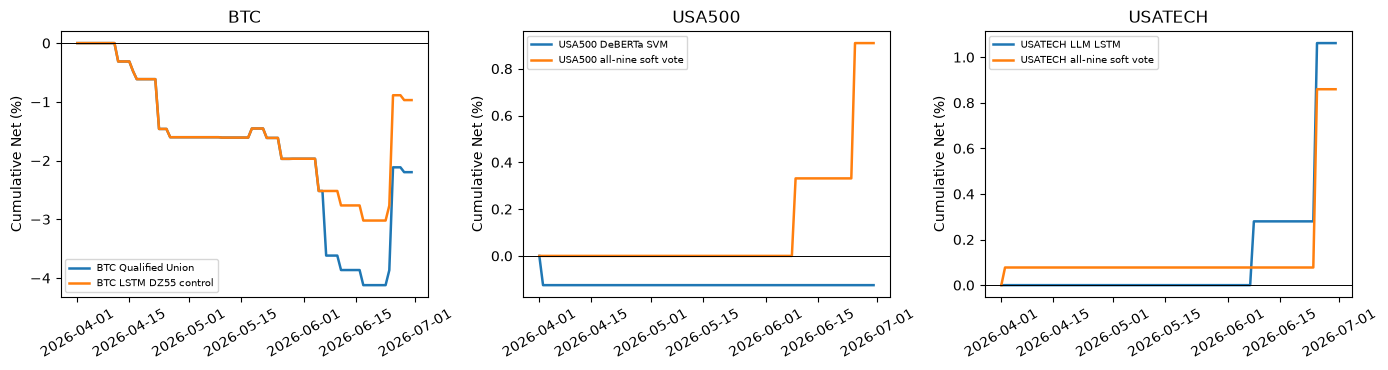

In [10]:
streams = {
    "BTC": ["btc_qualified_union_v1", "btc_lstm_dz55"],
    "USA500": ["usa500_best_single_deberta_svm", "usa500_deberta_soft_vote"],
    "USATECH": ["usatech_best_single_deepseek_lstm", "usatech_deepseek_soft_vote"],
}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=False)
for axis, (title, candidate_ids) in zip(axes, streams.items()):
    for candidate_id in candidate_ids:
        daily = read_table(f"daily__{candidate_id}").set_index("date")["net_return"]
        axis.plot(daily.index, 100 * daily.cumsum(), label=LABELS[candidate_id], linewidth=1.8)
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_title(title)
    axis.set_ylabel("Cumulative Net (%)")
    axis.tick_params(axis="x", rotation=30)
    axis.legend(fontsize=7)
fig.tight_layout()
plt.show()


In [11]:
verdict = json.loads(ARTIFACTS["verdict"].read_text(encoding="utf-8"))
for stream in ("USA500", "USATECH"):
    table = economics_table(stream.lower()).sort_values("Net %", ascending=False)


## Results

BTC Qualified Union returns -2.198% from 23 trades, versus -0.970% from 20 trades for LSTM. The paired difference is -1.227 percentage points, with a 95% interval rounded to [-3.55, 0.00], so the confirmatory test does not support Union. USA500 soft vote returns 0.910%; USATECH LLM LSTM and soft vote return 1.062% and 0.859%. These descriptive index results use only one to three trades per policy and no fresh scored Q2 sentiment. Three of six policies remain positive under doubled costs.

Takeaway: The completed Q2 evaluation does not confirm a BTC Union advantage; the sparse index results remain descriptive.
